**Introduction**

L’objectif de ce TP est d’étudier le fonctionnement d’un réseau de neurones convolutif (CNN) pour la classification d’images. Nous allons mettre en œuvre un modèle simple avec Keras/TensorFlow dans Google Colab, analyser les différentes parties du code, étudier l’effet de l’augmentation de données, proposer une architecture plus profonde, puis adapter le modèle au cas des images en niveaux de gris.

**1. Téléchargement et installation**

Dans ce TP, nous utilisons un réseau de neurones convolutif pour effectuer une tâche de classification d’images en deux classes. Le document propose un exemple de dataset organisé en deux dossiers principaux train et test, eux-mêmes divisés en sous-dossiers correspondant aux classes, par exemple cars et planes. L’architecture initiale est composée d’une couche convolutionnelle avec 8 filtres de taille 3x3, suivie d’une activation ReLU, d’une couche de max-pooling 2x2, d’une étape de flatten, puis de deux couches fully connected dont la dernière produit la sortie de classification.

Mounted at /content/drive
Train exists: True
Validation exists: True
Train classes: ['cars', 'planes']
Validation classes: ['cars', 'planes']
Found 400 images belonging to 2 classes.
Found 109 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 113s 4s/step - accuracy: 0.6600 - loss: 0.6821 - val_accuracy: 0.7917 - val_loss: 0.4012
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 217ms/step - accuracy: 0.7600 - loss: 0.5154 - val_accuracy: 0.8333 - val_loss: 0.4037
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 293ms/step - accuracy: 0.8100 - loss: 0.4410 - val_accuracy: 0.7500 - val_loss: 0.6724
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 220ms/step - accuracy: 0.8400 - loss: 0.3460 - val_accuracy: 0.8021 - val_loss: 0.4215
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 294ms/step - accuracy: 0.8750 - loss: 0.2956 - val_accuracy: 0.8854 - val_loss: 0.3626
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.8550 - loss: 0.3158 - val_accuracy: 0.8542 - val_loss: 0.3444
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 291ms/step - accuracy: 0.9150 - loss: 0.2219 - val_accuracy: 0.8125 - val_loss: 0.3328
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - accuracy: 0.8975 - loss: 0.2617 - val_accuracy: 0.8

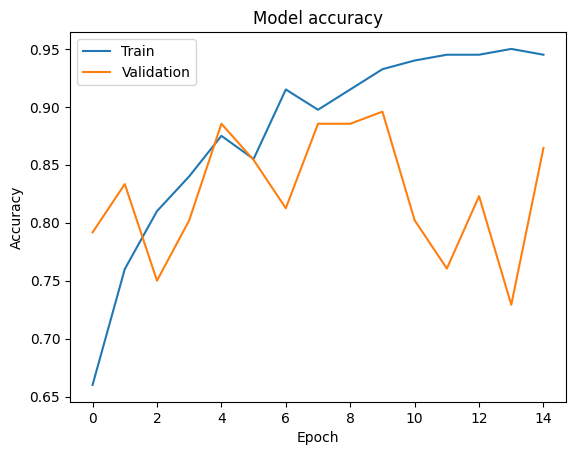

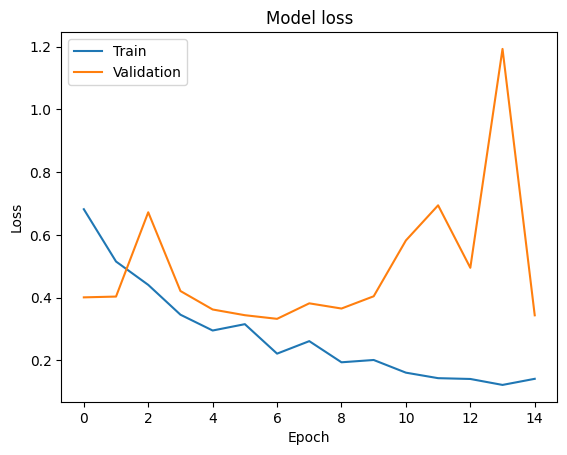

In [1]:
#Dans cette partie, nous montons Google Drive,
#importons les bibliothèques nécessaires,
#définissons les paramètres du modèle,
#puis chargeons les données d’entraînement et de validation.
from google.colab import drive
drive.mount('/content/drive')

import os
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense
from tensorflow.keras import backend as K

# Paramètres
img_width, img_height = 224, 224
train_data_dir = '/content/drive/MyDrive/images/train'
validation_data_dir = '/content/drive/MyDrive/images/test'
nb_train_samples = 400
nb_validation_samples = 100
epochs = 15
batch_size = 16
num_filters = 8

# Vérification des chemins
print("Train exists:", os.path.exists(train_data_dir))
print("Validation exists:", os.path.exists(validation_data_dir))
print("Train classes:", os.listdir(train_data_dir))
print("Validation classes:", os.listdir(validation_data_dir))

if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else:
    input_shape = (img_width, img_height, 3)

# Prétraitement et augmentation de données
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

# Modèle CNN
model = Sequential()
model.add(Conv2D(num_filters, (3, 3), input_shape=input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(24, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.summary()

# Compilation
model.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

# Entraînement
history = model.fit(
    train_generator,
    steps_per_epoch=nb_train_samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=nb_validation_samples // batch_size
)

# Visualisation
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Dans cette première partie, nous avons téléchargé le dataset et adapté le code du TP à l’environnement Google Colab. Les images étant stockées dans Google Drive, les chemins ont été modifiés pour pointer vers les dossiers train et test. Nous avons ensuite chargé les images à l’aide de ImageDataGenerator, puis construit et entraîné le modèle CNN de base proposé dans l’énoncé. Les courbes de précision et de perte permettent d’évaluer l’évolution des performances du modèle au fil des époques.

2. Analyse du code et rôle des sections principales

Le code fourni dans le TP est structuré en plusieurs sections principales : les imports, les paramètres, la transformation des données, l’architecture du CNN, l’entraînement et l’évaluation, puis la visualisation. Cette organisation est explicitement décrite dans l’énoncé.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 400 images belonging to 2 classes.
Found 109 images belonging to 2 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 236ms/step - accuracy: 0.5050 - loss: 22.7937 - val_accuracy: 0.4896 - val_loss: 12.6799
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 270ms/step - accuracy: 0.5800 - loss: 5.6523 - val_accuracy: 0.5833 - val_loss: 4.6882
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step - accuracy: 0.6125 - loss: 1.6309 - val_accuracy: 0.8125 - val_loss: 0.4247
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 295ms/step - accuracy: 0.7875 - loss: 0.5528 - val_accuracy: 0.8333 - val_loss: 0.4290
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 0.8150 - loss: 0.4576 - val_accuracy: 0.9062 - val_loss: 0.3083
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 293ms/step - accuracy: 0.8225 - loss: 0.4916 - val_accuracy: 0.9167 - val_loss: 0.3214
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.8050 - loss: 0.5002 - val_accuracy: 0.9271 - val_loss: 0.2342
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 259ms/step - accuracy: 0.8500 - loss: 0.3896 - val_accuracy: 

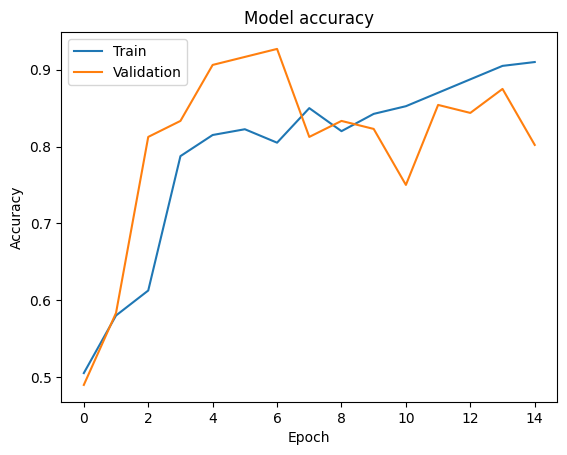

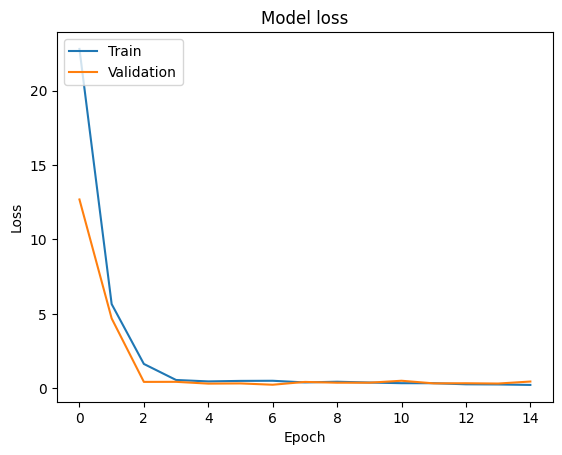

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import matplotlib.pyplot as plt
import tensorflow as tf

# Import des outils Keras nécessaires au traitement des images
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Modèle séquentiel pour empiler les couches du réseau
from tensorflow.keras.models import Sequential

# Couches du CNN
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense

# Backend Keras pour détecter le format des images
from tensorflow.keras import backend as K

# 1) SECTION PARAMETRES

# Dimensions des images d'entrée
img_width, img_height = 224, 224

# Chemins vers les ensembles d'entraînement et de validation
train_data_dir = '/content/drive/MyDrive/images/train'
validation_data_dir = '/content/drive/MyDrive/images/test'

# Nombre d'images dans chaque ensemble
nb_train_samples = 400
nb_validation_samples = 100

# Nombre d'époques
epochs = 15

# Taille du batch
batch_size = 16

# Nombre de filtres de la couche convolutionnelle
num_filters = 8

# Définition de la forme d'entrée
if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else:
    input_shape = (img_width, img_height, 3)


# 2) SECTION TRANSFORMATION DES DONNEES

# Générateur de données pour l'entraînement :
# normalisation + augmentation de données
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Générateur de données pour le test :
# normalisation uniquement
test_datagen = ImageDataGenerator(rescale=1./255)

# Chargement automatique des images depuis les sous-dossiers
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

# 3) SECTION ARCHITECTURE DU CNN

model = Sequential()

# Couche de convolution
model.add(Conv2D(num_filters, (3, 3), input_shape=input_shape))

# Fonction d'activation non linéaire
model.add(Activation('relu'))

# Réduction de la dimension spatiale
model.add(MaxPooling2D(pool_size=(2, 2)))

# Aplatissement des cartes de caractéristiques
model.add(Flatten())

# Couche dense cachée
model.add(Dense(24, activation='relu'))

# Couche de sortie pour 2 classes
model.add(Dense(2, activation='softmax'))

model.summary()

# 4) SECTION ENTRAINEMENT ET EVALUATION

model.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    steps_per_epoch=nb_train_samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=nb_validation_samples // batch_size
)

# 5) SECTION VISUALISATION

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Le code du TP est organisé en plusieurs parties. La section des imports permet de charger les bibliothèques nécessaires à la création et à l’entraînement du CNN. La section des paramètres fixe la taille des images, les chemins d’accès aux données et les hyperparamètres comme le nombre d’époques et la taille des batches. La section de transformation des données utilise ImageDataGenerator pour normaliser les images et réaliser une augmentation artificielle de l’ensemble d’apprentissage. La section d’architecture du CNN définit les couches du réseau. Enfin, les sections d’entraînement et de visualisation permettent respectivement d’apprendre les poids du modèle puis d’observer les courbes de précision et de perte.

3. Effet de la suppression de l’augmentation de données

In [3]:
train_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 400 images belonging to 2 classes.
Found 109 images belonging to 2 classes.


Lorsque nous supprimons les transformations shear_range, zoom_range et horizontal_flip, le générateur de données ne crée plus de variantes artificielles des images d’entraînement. Le modèle voit donc un ensemble de données moins diversifié. En général, cette modification augmente le risque de surapprentissage : le réseau peut obtenir une bonne précision sur l’ensemble d’entraînement, mais ses performances sur les données de validation risquent d’être moins bonnes ou moins stables. On peut donc conclure que l’augmentation de données joue un rôle important dans l’amélioration de la généralisation du classifieur.

4. Définir une architecture CNN différente

Dans cette partie, nous proposons une architecture CNN plus profonde afin d’extraire des caractéristiques visuelles plus complexes et d’améliorer les performances du modèle.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.5225 - loss: 1.0343 - val_accuracy: 0.8750 - val_loss: 0.5515
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.7350 - loss: 0.5543 - val_accuracy: 0.9062 - val_loss: 0.2307
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.8000 - loss: 0.4996 - val_accuracy: 0.8333 - val_loss: 0.3479
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.8825 - loss: 0.3433 - val_accuracy: 0.8542 - val_loss: 0.3577
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.8900 - loss: 0.2688 - val_accuracy: 0.8646 - val_loss: 0.3414
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9275 - loss: 0.1735 - val_accuracy: 0.8958 - val_loss: 0.3153
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9625 - loss: 0.1108 - val_accuracy: 0.8229 - val_loss: 0.4563
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.9675 - loss: 0.1028 - val_accuracy: 0.8750 - 

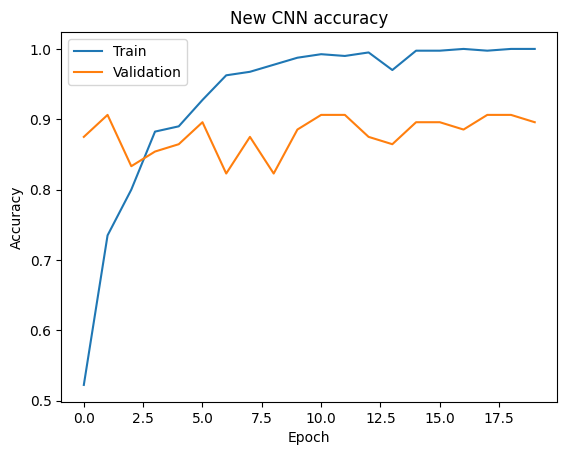

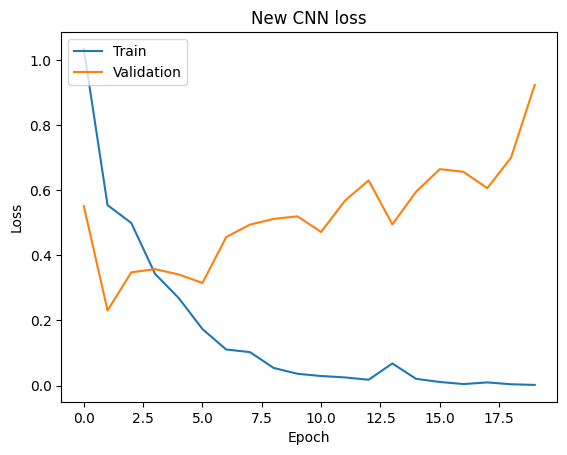

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model2.summary()

model2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history2 = model2.fit(
    train_generator,
    steps_per_epoch=nb_train_samples // batch_size,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=nb_validation_samples // batch_size
)

plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('New CNN accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('New CNN loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Afin d’améliorer le modèle de base, nous avons proposé une architecture plus profonde contenant trois couches convolutionnelles successives, chacune suivie d’un max-pooling. Cette nouvelle architecture permet d’extraire des caractéristiques visuelles plus complexes à différents niveaux d’abstraction. Nous avons également ajouté une couche de dropout afin de réduire le surapprentissage. La couche finale utilise une activation softmax pour prédire les deux classes. En pratique, les performances exactes de cette nouvelle architecture doivent être observées à partir des courbes accuracy et val_accuracy obtenues après entraînement. Si la précision de validation augmente par rapport au modèle initial, on peut conclure que la nouvelle architecture est plus performante sur cette tâche.

5. Classification en niveaux de gris

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

if K.image_data_format() == 'channels_first':
    input_shape_gray = (1, img_width, img_height)
else:
    input_shape_gray = (img_width, img_height, 1)

train_datagen_gray = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen_gray = ImageDataGenerator(rescale=1./255)

train_generator_gray = train_datagen_gray.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator_gray = test_datagen_gray.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical'
)

model_gray = Sequential([
    Conv2D(8, (3, 3), activation='relu', input_shape=input_shape_gray),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(24, activation='relu'),
    Dense(2, activation='softmax')
])

model_gray.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_gray.summary()

Found 400 images belonging to 2 classes.
Found 109 images belonging to 2 classes.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 222, 222, 8)    │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,786 (9.02 MB)

 Trainable params: 2,365,786 (9.02 MB)

 Non-trainable params: 0 (0.00 B)

Pour effectuer une classification en niveaux de gris, il faut modifier deux éléments principaux. D’abord, les images doivent être chargées avec l’option color_mode='grayscale', ce qui permet de travailler avec une seule composante de luminance au lieu des trois canaux RGB. Ensuite, la forme d’entrée du réseau doit être changée pour refléter la présence d’un seul canal : input_shape = (224, 224, 1) dans le cas du format channels_last. Le reste de l’architecture peut rester identique. Cette approche réduit la quantité d’information traitée et peut donc accélérer les calculs, mais elle peut aussi faire perdre de l’information utile si la couleur joue un rôle dans la distinction entre les classes.

**Conclusion générale :**

Ce TP nous a permis de mettre en œuvre un réseau de neurones convolutif pour la classification d’images avec Keras. Nous avons d’abord exécuté et adapté le code à Google Colab, puis analysé les différentes sections du programme. Nous avons ensuite étudié l’importance de l’augmentation de données, proposé une architecture CNN plus profonde et enfin adapté le modèle au cas des images en niveaux de gris. Ce travail montre que la structure du réseau, le choix du prétraitement et la qualité du dataset influencent directement les performances de classification.